In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print("Classes:", data.target_names)
print("Shape:", X.shape)


Classes: ['malignant' 'benign']
Shape: (569, 30)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [5]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)


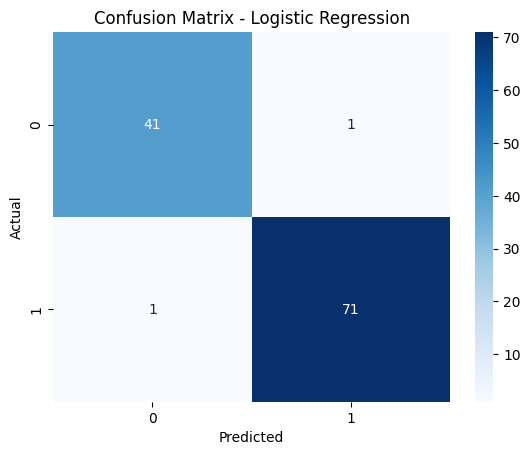

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [6]:
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

print(classification_report(y_test, y_pred_lr))


.True Positives (TP): Correctly predicted malignant cases.

.True Negatives (TN): Correctly predicted benign cases.

.False Positives (FP): Benign cases wrongly predicted as malignant (unnecessary alarm).

.False Negatives (FN): Malignant cases wrongly predicted as benign (most dangerous error in medical diagnosis).


#Why accuracy alone is insufficient:

Accuracy can look high even if the model misses critical malignant cases.


#Which metric is more important for medical diagnosis?  
Recall is most important — we want to catch as many malignant cases as possible, even at the cost of some false alarms.

#What happens if recall is low?  
Many malignant cases will be missed → patients wrongly told they are healthy → dangerous consequences.

#Why is F1‑score preferred for imbalanced data?

F1 combines precision and recall into one balanced metric.

In imbalanced datasets, accuracy is misleading, but F1 gives a fairer view of performance.

It ensures the model is not only precise but also sensitive to minority classes.


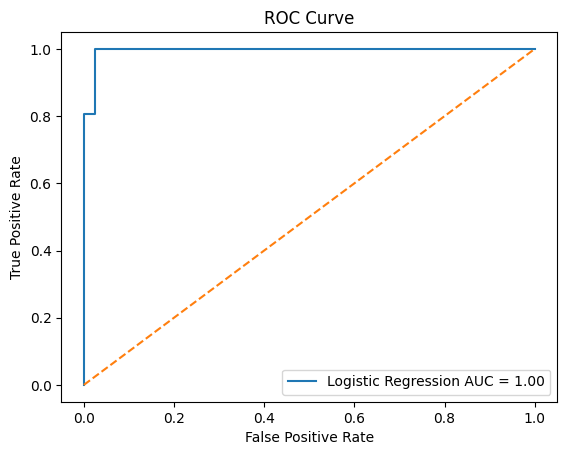

In [7]:
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {auc_lr:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [8]:
log_reg_balanced = LogisticRegression(class_weight="balanced", max_iter=1000)
log_reg_balanced.fit(X_train_scaled, y_train)

y_pred_bal = log_reg_balanced.predict(X_test_scaled)
print(classification_report(y_test, y_pred_bal))


              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



In [9]:
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
print(classification_report(y_test, y_pred_tree))


              precision    recall  f1-score   support

           0       0.85      0.93      0.89        42
           1       0.96      0.90      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.92      0.91       114
weighted avg       0.92      0.91      0.91       114



#Logistic Regression:

Stable, less prone to overfitting.

Performs well with scaled features.

Strong ROC‑AUC, interpretable coefficients.

#Decision Tree:

Easy to interpret (rules are human‑readable).

Can capture non‑linear relationships.

But prone to overfitting unless pruned or regularized.


#Logistic Regression (Stability):

Produces consistent results across different train/test splits.

Less sensitive to noise in the dataset.

Works well with scaled features and avoids wild swings in predictions.

Stability makes it more reliable for deployment in critical domains (like healthcare).

#Decision Tree (Interpretability):

Easy to understand — rules can be visualized (“if feature > threshold → class”).

Non‑technical stakeholders (like doctors or managers) can interpret the decision path.

However, interpretability comes at the cost of stability — small changes in data can drastically change the tree structure.

#Logistic Regression:

Less prone to overfitting because it’s a linear model.

Regularization (like class_weight or penalty) can further control complexity.

Generalizes better to unseen data.

Decision Tree:

Very prone to overfitting if depth is not limited.

Can memorize training data perfectly (high training accuracy, poor test accuracy).

Needs pruning or hyperparameter tuning (max_depth, min_samples_split) to reduce overfitting.